# Figure S2C

### Complete genomes and fragments from figure 2b were used

In [ ]:
%%bash
### Ran bacphlip on all complete genomes and their fragments

# # the following code was run on each fasta
# bacphlip \
#     --input_file ${gunzipped_fasta} \
#     --force_overwrite \
#     --multi_fasta

In [1]:
### Load bacphlip results for fragmented genomes
import polars as pl
import glob

frag_bacphlip_lst = []

for file in glob.glob("bacphlip_results/uhgv_complete_*_num1_*.bacphlip.gz"):
    sample= file.rpartition('/')[-1].split('rand1000_')[1].split('.fa')[0]
    df = (
        pl.read_csv(file, separator="\t")
            .with_columns([
                pl.lit(sample).str.split('_').list[2].str.split('.').list[0].alias('cat'),
                pl.lit(sample).str.split('_').list[0].str.replace('iter', '').cast(pl.Float64).alias('iter'),
                pl.col('').str.split('_iter').list[0].alias('contig_id')
            ])
    )
    frag_bacphlip_lst.append(df)

frag_bacphlip_df = pl.concat(frag_bacphlip_lst)

In [2]:
### Load bacphlip results for complete genomes
comp_bacphlip_lst = []

for file in glob.glob("bacphlip_results/uhgv_complete_votu*_complete.fna.bacphlip.gz"):
    sample= file.rpartition('/')[-1].split('rand1000_')[1].split('.fa')[0]
    df = (
        pl.read_csv(file, separator="\t")
            .with_columns([
                pl.lit('complete').alias('cat'),
                pl.lit(sample).str.split('_').list[0].str.split('.fna').list[0].cast(pl.Float64).alias('iter'),
                pl.col('').alias('contig_id')
            ])
    )
    comp_bacphlip_lst.append(df)

comp_bacphlip_df = pl.concat(comp_bacphlip_lst)

# join fragmented and complete bacphlip results
bacphlip_join_df = frag_bacphlip_df.join(comp_bacphlip_df, on='contig_id', suffix='_complete', how='inner')
bacphlip_concat_df = pl.concat([frag_bacphlip_df, comp_bacphlip_df])

Text(0.5, 1.0, 'Complete vs fragment lifestyle predictions')

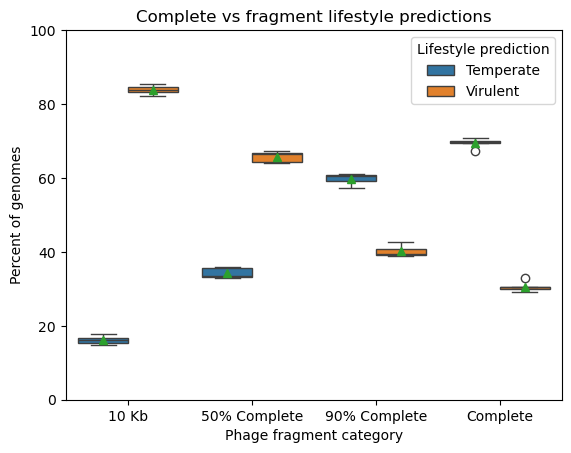

In [6]:
### Plot proportion of sequences predicted temperate vs virulent across fragment categories
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = (
    bacphlip_concat_df
        .with_columns([
            pl.when((pl.col('Temperate')) >= 0.5)
                .then(pl.lit('Temperate'))
                .otherwise(pl.lit('Virulent'))
                .alias('Lifestyle prediction')
        ])
        .group_by(['Lifestyle prediction', 'cat', 'iter'])
        .len()
        .with_columns([
            (pl.col('len') / 10).alias('percent'),
            pl.col('cat').str.replace('len10000', '10 Kb').str.replace('len50', '50% complete').str.replace('len90', '90% complete').str.replace('complete', 'Complete').alias('cat')
        ])
)

sns.boxplot(data=plot_df, x='cat', y='percent', hue='Lifestyle prediction', showmeans=True, order=['10 Kb', '50% Complete', '90% Complete', 'Complete'])
plt.ylim(0, 100)
plt.ylabel('Percent of genomes')
plt.xlabel('Phage fragment category')
plt.title('Complete vs fragment lifestyle predictions')

In [5]:
plot_df.group_by(['cat', 'Lifestyle prediction']).agg([
    pl.mean('percent').alias('mean_percent')
])

cat,Lifestyle prediction,mean_percent
str,str,f64
"""50% Complete""","""Temperate""",34.22
"""10 Kb""","""Temperate""",16.12
"""90% Complete""","""Virulent""",40.22
"""90% Complete""","""Temperate""",59.78
"""50% Complete""","""Virulent""",65.78
"""Complete""","""Temperate""",69.44
"""Complete""","""Virulent""",30.56
"""10 Kb""","""Virulent""",83.88
